### Overview

Evaluation of rank-based machine learning models using TCGA-BRCA test set (fully external test set)

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
import random
import matplotlib.pyplot as plt
import seaborn as sns

#### 1. Import and prepare input data

In [2]:
# import tpm counts training set
train_data = pd.read_csv("C:/Users/User/Documents/master_thesis_project_analysis/datasets/SCANB_GSE202203/scanb_hiseq_train_test_sets/train_test_80_20/SCANB_HiSeq_pam50gene_tpm_counts_subtype_train_80.csv", 
                          header=0, index_col=0)

In [3]:
# import validation data
val_data = pd.read_csv("C:/Users/User/Documents/master_thesis_project_analysis/datasets/TCGA_BRCA/tcga_brca_cleaned_data/pam50genes_tpm_counts_subtype_tcga_brca.csv", 
                       header=0, index_col=0)

In [4]:
# keep only PAM50 gene counts
X_train = train_data.iloc[:, 0:50]
X_test = val_data.iloc[:,0:50]
print(X_train.shape)
print(X_test.shape)
print(X_train.columns.equals(X_test.columns))

(2204, 50)
(1031, 50)
True


In [5]:
# save sample subtype info separately as y_train and y_test
y_train = train_data.iloc[:, [50]]
y_test = val_data.iloc[:,[50]]
print(y_train.shape)
print(y_test.shape)

(2204, 1)
(1031, 1)


In [6]:
# check if the indices of x and y match
print(X_train.index.equals(y_train.index))
print(X_test.index.equals(y_test.index))

True
True


In [7]:
# label encoding
label_encoder = LabelEncoder()
y_train['subtype'] = label_encoder.fit_transform(y_train['subtype'])
y_test['subtype'] = label_encoder.transform(y_test['subtype'])

# check class count before label encoding
print("Class count before label encoding")
print("Train set\n",train_data['subtype'].value_counts())
print("\nTest set\n",val_data['subtype'].value_counts())

# check class count after label encoding
print("\nClass count after label encoding")
print("Train set\n",y_train['subtype'].value_counts())
print("\nTest set\n",y_test['subtype'].value_counts())

Class count before label encoding
Train set
 subtype
LumA     1119
LumB      654
Basal     230
Her2      201
Name: count, dtype: int64

Test set
 subtype
LumA     555
LumB     209
Basal    185
Her2      82
Name: count, dtype: int64

Class count after label encoding
Train set
 subtype
2    1119
3     654
0     230
1     201
Name: count, dtype: int64

Test set
 subtype
2    555
3    209
0    185
1     82
Name: count, dtype: int64


C:\Users\User\AppData\Local\Temp\ipykernel_6084\535389317.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y_train['subtype'] = label_encoder.fit_transform(y_train['subtype'])
C:\Users\User\AppData\Local\Temp\ipykernel_6084\535389317.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y_test['subtype'] = label_encoder.transform(y_test['subtype'])


In [8]:
# replace gene values by the rank
X_train_ranked = X_train.rank(axis=1, method="min", ascending=False).astype('int')
X_test_ranked = X_test.rank(axis=1, method="min", ascending=False).astype('int')

In [9]:
# scale the ranks between 0 and 1 for each sample
max_rank = len(X_train.columns)
X_train_ranked_scaled = X_train_ranked.apply(lambda row: (row-1) / (max_rank-1), axis=1)
X_test_ranked_scaled = X_test_ranked.apply(lambda row: (row-1) / (max_rank-1), axis=1)

In [10]:
print(X_train_ranked_scaled.shape)
print(X_test_ranked_scaled.shape)

(2204, 50)
(1031, 50)


In [11]:
seed = 42
np.random.seed(seed)
random.seed(seed)

#### 2. Evaluate model performance on the test set

#### 2.1 Random Forest

In [12]:
random.seed(seed)
np.random.seed(seed)

# build rf classifier
rfc = RandomForestClassifier(n_estimators=200, min_samples_leaf=1, min_samples_split=8, max_depth=None, random_state=seed)

# fit the rf classifier on the training fold sets
rfc.fit(X_train_ranked_scaled, y_train.values.ravel())

# make predictions on the validation fold set
y_pred_rf = rfc.predict(X_test_ranked_scaled)

# calculate metric scores
mcc_rf = metrics.matthews_corrcoef(y_test.values.ravel(), y_pred_rf)
f1_rf = metrics.f1_score(y_test.values.ravel(), y_pred_rf, average='macro')
recall_rf = metrics.recall_score(y_test.values.ravel(), y_pred_rf, average='macro')
precision_rf = metrics.precision_score(y_test.values.ravel(), y_pred_rf, average='macro')
accuracy_rf = metrics.accuracy_score(y_test.values.ravel(), y_pred_rf)

print(metrics.classification_report(y_test.values.ravel(), y_pred_rf, digits=4))


              precision    recall  f1-score   support

           0     0.9945    0.9838    0.9891       185
           1     0.8810    0.9024    0.8916        82
           2     1.0000    0.4721    0.6414       555
           3     0.4104    0.9856    0.5795       209

    accuracy                         0.7022      1031
   macro avg     0.8215    0.8360    0.7754      1031
weighted avg     0.8700    0.7022    0.7111      1031



In [13]:
print('Accuracy: ', round(accuracy_rf,4))
print('Macro Precision: ', round(precision_rf,4))
print('Macro Recall: ', round(recall_rf,4))
print('Macro F1: ', round(f1_rf,4))
print('Macro MCC: ', round(mcc_rf,4))

Accuracy:  0.7022
Macro Precision:  0.8215
Macro Recall:  0.836
Macro F1:  0.7754
Macro MCC:  0.6639


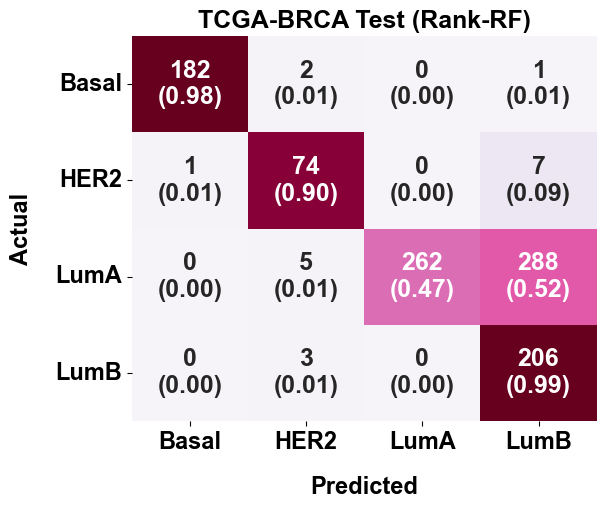

In [14]:
# Compute actual and normalized confusion matrices
cm_actual = metrics.confusion_matrix(y_test.values.ravel(), y_pred_rf, labels=[0,1,2,3])
cm_normalized = metrics.confusion_matrix(y_test.values.ravel(), y_pred_rf, labels=[0,1,2,3], normalize='true')

# Define class labels
new_labels = ['Basal', 'HER2', 'LumA', 'LumB']

# Create formatted annotations combining actual counts and normalized values
annotations = np.array([
    [f"{cm_actual[i, j]}\n({cm_normalized[i, j]:.2f})" for j in range(cm_actual.shape[1])]
    for i in range(cm_actual.shape[0])
])

# Convert normalized confusion matrix to DataFrame for visualization
cm_df = pd.DataFrame(cm_normalized, index=new_labels, columns=new_labels)

# Plot heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm_df, annot=annotations, fmt='', cmap='PuRd', cbar=False, 
            annot_kws={"size": 18, "family": 'Arial', 'weight':'bold'})

# Formatting labels and title
plt.xticks(fontsize=17, fontfamily='Arial', rotation=0, weight='bold')  
plt.yticks(fontsize=17, fontfamily='Arial', rotation=0, weight='bold') 
plt.xlabel('Predicted', fontsize=17, fontfamily='Arial', labelpad=16, weight='bold')
plt.ylabel('Actual', fontsize=17, fontfamily='Arial', labelpad=16, weight='bold')
plt.title('TCGA-BRCA Test (Rank-RF)', fontsize=18, fontfamily='Arial', weight='bold')
plt.show()

#### 2.2 SVM

In [15]:
random.seed(seed)
np.random.seed(seed)
    
# build svm classifier
svm = SVC(C=1, gamma=1, kernel='rbf', random_state=seed)

# fit the svm classifier on the training fold sets
svm.fit(X_train_ranked_scaled, y_train.values.ravel())

# make predictions on the validation fold set
y_pred_svm = svm.predict(X_test_ranked_scaled)

# calculate metric scores
mcc_svm = metrics.matthews_corrcoef(y_test.values.ravel(), y_pred_svm)
f1_svm = metrics.f1_score(y_test.values.ravel(), y_pred_svm, average='macro')
recall_svm = metrics.recall_score(y_test.values.ravel(), y_pred_svm, average='macro')
precision_svm = metrics.precision_score(y_test.values.ravel(), y_pred_svm, average='macro')
accuracy_svm = metrics.accuracy_score(y_test.values.ravel(), y_pred_svm)

print(metrics.classification_report(y_test.values.ravel(), y_pred_svm, digits=4))


              precision    recall  f1-score   support

           0     1.0000    0.9892    0.9946       185
           1     0.8211    0.9512    0.8814        82
           2     1.0000    0.5117    0.6770       555
           3     0.4307    0.9665    0.5959       209

    accuracy                         0.7245      1031
   macro avg     0.8129    0.8547    0.7872      1031
weighted avg     0.8704    0.7245    0.7338      1031



In [16]:
print('Accuracy: ', round(accuracy_svm,4))
print('Macro Precision: ', round(precision_svm,4))
print('Macro Recall: ', round(recall_svm,4))
print('Macro F1: ', round(f1_svm,4))
print('Macro MCC: ', round(mcc_svm,4))

Accuracy:  0.7245
Macro Precision:  0.8129
Macro Recall:  0.8547
Macro F1:  0.7872
Macro MCC:  0.6808


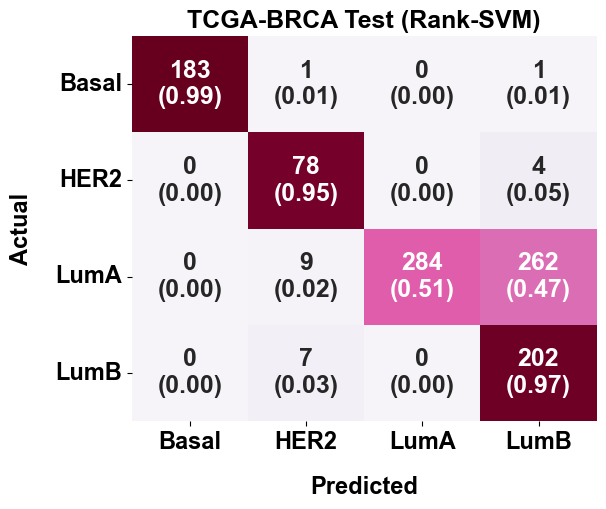

In [17]:
# Compute actual and normalized confusion matrices
cm_actual = metrics.confusion_matrix(y_test.values.ravel(), y_pred_svm, labels=[0,1,2,3])
cm_normalized = metrics.confusion_matrix(y_test.values.ravel(), y_pred_svm, labels=[0,1,2,3], normalize='true')

# Define class labels
new_labels = ['Basal', 'HER2', 'LumA', 'LumB']

# Create formatted annotations combining actual counts and normalized values
annotations = np.array([
    [f"{cm_actual[i, j]}\n({cm_normalized[i, j]:.2f})" for j in range(cm_actual.shape[1])]
    for i in range(cm_actual.shape[0])
])

# Convert normalized confusion matrix to DataFrame for visualization
cm_df = pd.DataFrame(cm_normalized, index=new_labels, columns=new_labels)

# plot heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm_df, annot=annotations, fmt='', cmap='PuRd', cbar=False, 
            annot_kws={"size": 18, "family": 'Arial', 'weight':'bold'})

# Formatting labels and title
plt.xticks(fontsize=17, fontfamily='Arial', rotation=0, weight='bold')  
plt.yticks(fontsize=17, fontfamily='Arial', rotation=0, weight='bold') 
plt.xlabel('Predicted', fontsize=17, fontfamily='Arial', labelpad=16, weight='bold')
plt.ylabel('Actual', fontsize=17, fontfamily='Arial', labelpad=16, weight='bold')
plt.title('TCGA-BRCA Test (Rank-SVM)', fontsize=18, fontfamily='Arial', weight='bold')
# plt.savefig('tcga_brca_test_rank_svm_confusionmatrix.png',dpi=300, bbox_inches='tight')
plt.show()

#### 2.3 Logistic Regression

In [18]:
random.seed(seed)
np.random.seed(seed)

# build logistic regression classifier
lr = LogisticRegression(C=5, penalty='l2', solver='lbfgs', random_state=seed, max_iter=2000)

# fit the logistic regression classifier on the training fold sets
lr.fit(X_train_ranked_scaled, y_train.values.ravel())

# make predictions on the validation fold set
y_pred_logreg = lr.predict(X_test_ranked_scaled)

# calculate metric scores
mcc_logreg = metrics.matthews_corrcoef(y_test.values.ravel(), y_pred_logreg)
f1_logreg = metrics.f1_score(y_test.values.ravel(), y_pred_logreg, average='macro')
recall_logreg = metrics.recall_score(y_test.values.ravel(), y_pred_logreg, average='macro')
precision_logreg = metrics.precision_score(y_test.values.ravel(), y_pred_logreg, average='macro')
accuracy_logreg = metrics.accuracy_score(y_test.values.ravel(), y_pred_logreg)

print(metrics.classification_report(y_test.values.ravel(), y_pred_logreg, digits=4))



              precision    recall  f1-score   support

           0     0.9946    0.9892    0.9919       185
           1     0.7383    0.9634    0.8360        82
           2     1.0000    0.5333    0.6957       555
           3     0.4527    0.9617    0.6156       209

    accuracy                         0.7362      1031
   macro avg     0.7964    0.8619    0.7848      1031
weighted avg     0.8673    0.7362    0.7437      1031



In [19]:
print('Accuracy: ', round(accuracy_logreg,4))
print('Macro Precision: ', round(precision_logreg,4))
print('Macro Recall: ', round(recall_logreg,4))
print('Macro F1: ', round(f1_logreg,4))
print('Macro MCC: ', round(mcc_logreg,4))

Accuracy:  0.7362
Macro Precision:  0.7964
Macro Recall:  0.8619
Macro F1:  0.7848
Macro MCC:  0.6886


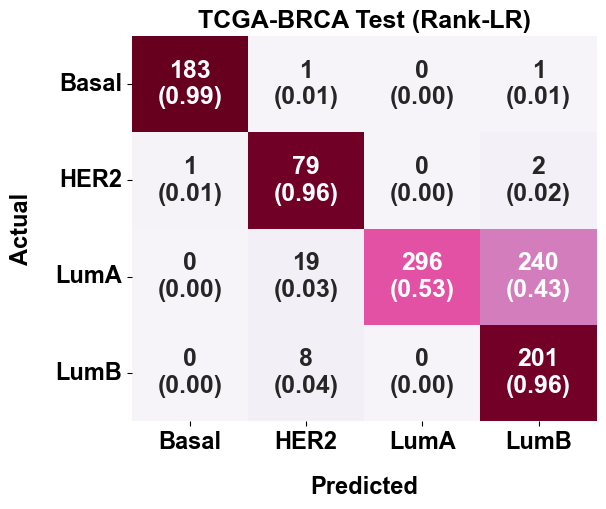

In [20]:
# Compute actual and normalized confusion matrices
cm_actual = metrics.confusion_matrix(y_test.values.ravel(), y_pred_logreg, labels=[0,1,2,3])
cm_normalized = metrics.confusion_matrix(y_test.values.ravel(), y_pred_logreg, labels=[0,1,2,3], normalize='true')

# Define class labels
new_labels = ['Basal', 'HER2', 'LumA', 'LumB']

# Create formatted annotations combining actual counts and normalized values
annotations = np.array([
    [f"{cm_actual[i, j]}\n({cm_normalized[i, j]:.2f})" for j in range(cm_actual.shape[1])]
    for i in range(cm_actual.shape[0])
])

# Convert normalized confusion matrix to DataFrame for visualization
cm_df = pd.DataFrame(cm_normalized, index=new_labels, columns=new_labels)

# Plot heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm_df, annot=annotations, fmt='', cmap='PuRd', cbar=False, 
            annot_kws={"size": 18, "family": 'Arial', 'weight':'bold'})

# Formatting labels and title
plt.xticks(fontsize=17, fontfamily='Arial', rotation=0, weight='bold')  
plt.yticks(fontsize=17, fontfamily='Arial', rotation=0, weight='bold') 
plt.xlabel('Predicted', fontsize=17, fontfamily='Arial', labelpad=16, weight='bold')
plt.ylabel('Actual', fontsize=17, fontfamily='Arial', labelpad=16, weight='bold')
plt.title('TCGA-BRCA Test (Rank-LR)', fontsize=18, fontfamily='Arial', weight='bold')
plt.show()

#### 3. Merge predicted labels of SVM (best model) with actual labels and survival information

This was created for survival analysis based on model predictions.

In [21]:
# import survival and subtype data of validation set
val_survival_subtype = pd.read_csv("C:/Users/User/Documents/master_thesis_project_analysis/datasets/TCGA_BRCA/tcga_brca_cleaned_data/tcga_brca_survival_subtype.csv",
                                           header=0, index_col=0)

# reorder the index in survival data according to the counts_subtype data
val_survival_subtype = val_survival_subtype.loc[val_data.index,:]
print('Index of survival data matches with index of gene exp data:', val_survival_subtype.index.equals(val_data.index))

# check whether the subtype column in subtype data is same as subtype column in gene exp data
print('Subtype column of survival data matches with subtype column of gene exp data:',
      val_survival_subtype['subtype'].tolist() == val_data['subtype'].tolist())


Index of survival data matches with index of gene exp data: True
Subtype column of survival data matches with subtype column of gene exp data: True


In [22]:
# define best model
best_model_res = y_pred_svm

# define labels to transform the numeric class labels into subtype names
labels_reverse = {0: 'Basal', 1: 'Her2', 2: 'LumA', 3: 'LumB'}

# convert predicted results of best model into a df
best_model_res_df = pd.DataFrame(best_model_res, index=y_test.index, columns=['predicted_subtype'])
best_model_res_df['predicted_subtype'] = best_model_res_df['predicted_subtype'].replace(labels_reverse)
best_model_res_df['predicted_subtype'].value_counts()

predicted_subtype
LumB     469
LumA     284
Basal    183
Her2      95
Name: count, dtype: int64

In [23]:
# merge survival data, actual labels and predicted labels
best_model_res_survival = val_survival_subtype.join(best_model_res_df)

# get the count of misclassifications
print('Number of misclassifications:', best_model_res_survival.loc[best_model_res_survival['subtype'] 
      != best_model_res_survival['predicted_subtype'],:].shape)

Number of misclassifications: (284, 7)


In [24]:
# check overall survival events
print("Survival event proportion:")
print(best_model_res_survival['vital_status'].value_counts())

# check overall survival events as per actual labels
print("\nSurvival event proportion based on actual subtype labels:")
# check survival events with actual labels
print(best_model_res_survival.loc[best_model_res_survival['subtype'] == 'LumA', 'vital_status'].value_counts())
print(best_model_res_survival.loc[best_model_res_survival['subtype'] == 'LumB', 'vital_status'].value_counts())
print(best_model_res_survival.loc[best_model_res_survival['subtype'] == 'Her2', 'vital_status'].value_counts())
print(best_model_res_survival.loc[best_model_res_survival['subtype'] == 'Basal', 'vital_status'].value_counts())

# check overall survival events as per predicted labels
print("\nSurvival event proportion based on predicted subtype labels:")
# check survival events with actual labels
print(best_model_res_survival.loc[best_model_res_survival['predicted_subtype'] == 'LumA', 'vital_status'].value_counts())
print(best_model_res_survival.loc[best_model_res_survival['predicted_subtype'] == 'LumB', 'vital_status'].value_counts())
print(best_model_res_survival.loc[best_model_res_survival['predicted_subtype'] == 'Her2', 'vital_status'].value_counts())
print(best_model_res_survival.loc[best_model_res_survival['predicted_subtype'] == 'Basal', 'vital_status'].value_counts())

Survival event proportion:
vital_status
Alive    888
Dead     143
Name: count, dtype: int64

Survival event proportion based on actual subtype labels:
vital_status
Alive    488
Dead      67
Name: count, dtype: int64
vital_status
Alive    176
Dead      33
Name: count, dtype: int64
vital_status
Alive    65
Dead     17
Name: count, dtype: int64
vital_status
Alive    159
Dead      26
Name: count, dtype: int64

Survival event proportion based on predicted subtype labels:
vital_status
Alive    256
Dead      28
Name: count, dtype: int64
vital_status
Alive    398
Dead      71
Name: count, dtype: int64
vital_status
Alive    77
Dead     18
Name: count, dtype: int64
vital_status
Alive    157
Dead      26
Name: count, dtype: int64


In [25]:
# create actual_pred column (eg: LumA_LumB)
best_model_res_survival['actual_pred'] = best_model_res_survival['subtype']
for i in range(best_model_res_survival.shape[0]):
    actual_subtype =  best_model_res_survival.loc[best_model_res_survival.index[i], 'subtype']
    pred_subtype =  best_model_res_survival.loc[best_model_res_survival.index[i], 'predicted_subtype']
    best_model_res_survival.loc[best_model_res_survival.index[i], 'actual_pred'] = f"{actual_subtype}__{pred_subtype}"

best_model_res_survival.head(4)

,vital_status,days_to_last_follow_up,days_to_death,overall_survival_days,overall_survival_years,subtype,predicted_subtype,actual_pred
TCGA-D8-A146-01A-31R-A115-07,Alive,643.0,NaN,643.0,1.760,LumA,LumA,LumA__LumA
TCGA-AQ-A0Y5-01A-11R-A14M-07,Dead,NaN,172.0,172.0,0.471,LumA,Her2,LumA__Her2
TCGA-C8-A274-01A-11R-A16F-07,Alive,508.0,NaN,508.0,1.391,LumB,LumB,LumB__LumB
TCGA-BH-A0BD-01A-11R-A034-07,Alive,554.0,NaN,554.0,1.517,LumB,LumB,LumB__LumB


In [26]:
# # save predicted + actual labels + survival data
# best_model_res_survival.to_csv('tcga_brca_rank_svm_predictions.csv')